# 04 — Modernização: do GPT-2 ao LLaMA

> Escopo: as quatro modernizações do padrão LLaMA. Ponto de partida: a arquitetura base GPT-2 do
> notebook 03. Aqui trocamos, peça por peça, os quatro componentes que a
> comunidade aposentou nos últimos cinco anos.

O GPT-2 (2019) já é um transformer decoder-only competente. O que mudou de lá pra
cá — e virou padrão de fato em LLaMA, Mistral, Gemma, DeepSeek — foram **quatro
trocas cirúrgicas**. Cada uma é independente em código, mas juntas transformam o
modelo. Neste notebook derivamos, implementamos e **verificamos numericamente**
cada uma:

| Componente GPT-2 | Substituto LLaMA | Ganho |
|---|---|---|
| LayerNorm | **RMSNorm** | ~15% menos operações, mesma qualidade |
| MLP GELU 4d | **SwiGLU** | mais expressividade por parâmetro |
| Pos-emb somado | **RoPE** | posição relativa, extrapola contexto |
| Geração ingênua | **KV-cache** | inferência O(N) em vez de O(N²) |

**O que você vai sair sabendo:**
1. Por que dá pra jogar fora a centralização da média (RMSNorm) sem perder nada.
2. Como um ramo multiplicativo (gate) deixa a MLP mais expressiva (SwiGLU).
3. Por que rotacionar Q/K codifica posição *relativa* — a mágica do RoPE.
4. Por que cachear K,V torna a geração linear, e como provar que dá o mesmo resultado.

Este notebook é a base direta dos stubs em
`src/tucanoce/model/layers/{rmsnorm,swiglu,rope,attention}.py`.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Convenção visual do projeto (idêntica ao nb 00).
plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})
torch.manual_seed(0)
np.random.seed(0)
torch.set_printoptions(precision=4, sci_mode=False)
print("torch", torch.__version__)

torch 2.12.1+cpu


## A. RMSNorm — normalização sem centralizar

### Recapitulação: LayerNorm

LayerNorm normaliza cada vetor de ativação $x \in \mathbb{R}^d$ pela sua própria
estatística e aplica um afim aprendido:

$$ \mu = \frac{1}{d}\sum_{i=1}^{d} x_i, \qquad
   \sigma^2 = \frac{1}{d}\sum_{i=1}^{d}(x_i - \mu)^2 $$
$$ \mathrm{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}} + \beta $$

São **duas** operações compostas: **re-centralizar** (subtrair a média) e
**re-escalar** (dividir pelo desvio). Os parâmetros $\gamma, \beta \in \mathbb{R}^d$
deixam o bloco seguinte recuperar escala/deslocamento se precisar.

### A observação-chave

Zhang & Sennrich notaram que a raiz da média dos quadrados (RMS)

$$ \mathrm{RMS}(x) = \sqrt{\tfrac{1}{d}\sum_i x_i^2} $$

se relaciona com a variância por uma identidade limpa:

$$ \mathrm{RMS}(x)^2 = \frac{1}{d}\sum_i x_i^2
   = \frac{1}{d}\sum_i \big[(x_i-\mu)^2 + 2\mu(x_i-\mu) + \mu^2\big]
   = \sigma^2 + \mu^2 $$

porque $\sum_i (x_i - \mu) = 0$ por definição de $\mu$. Ou seja: **RMS = σ quando
μ = 0**, e o termo $\mu^2$ é exatamente a "inflação" que o RMS captura além da
variância. Vamos conferir essa identidade no código antes de usá-la.

In [2]:
# Verificando RMS^2 = sigma^2 + mu^2 numericamente
x = torch.randn(1000) * 3 + 5.0          # média ~5, desvio ~3 (media != 0 de propósito)
mu = x.mean()
var = x.var(unbiased=False)              # sigma^2 populacional (divide por d)
rms_sq = x.pow(2).mean()                 # RMS^2 = mean(x^2)

print(f"mu           = {mu:.4f}")
print(f"sigma^2      = {var:.4f}")
print(f"mu^2         = {mu**2:.4f}")
print(f"sigma^2+mu^2 = {var + mu**2:.4f}")
print(f"RMS^2        = {rms_sq:.4f}")
assert torch.allclose(rms_sq, var + mu**2, atol=1e-3)
print("\nIdentidade RMS^2 = sigma^2 + mu^2 confirmada.")

mu           = 5.0868
sigma^2      = 9.5144
mu^2         = 25.8751
sigma^2+mu^2 = 35.3895
RMS^2        = 35.3895

Identidade RMS^2 = sigma^2 + mu^2 confirmada.


### Definição de RMSNorm

RMSNorm usa **apenas** o RMS como denominador — descarta a subtração da média e o
bias $\beta$:

$$ \mathrm{RMSNorm}(x) = \gamma \odot \frac{x}{\sqrt{\tfrac{1}{d}\sum_i x_i^2 + \varepsilon}} $$

**Intuição geométrica:** como $\|x\|_2 = \sqrt{d}\cdot\mathrm{RMS}(x)$, temos
$x/\mathrm{RMS}(x) = \sqrt{d}\cdot x/\|x\|_2$ — ou seja, projeta $x$ na esfera de
raio $\sqrt{d}$ antes da escala $\gamma$. A normalização **preserva direção e
descarta magnitude**. Perde o deslocamento da média; ganha simplicidade.

### Por que descartar a centralização funciona

1. **Composição com a camada seguinte.** O bloco logo após a norma é um afim
   $W^\top x + b$. Se a norma removesse a média $\mu$, o bias $b$ poderia
   reintroduzir qualquer média desejada. Remover a operação delega o ajuste de
   média ao $b$ aprendido — *efeito redundante*.
2. **Invariância a escala basta.** Em transformers, o que desestabiliza o treino é
   a explosão de magnitude do estado residual, não o deslocamento da média. RMS
   captura magnitude — dividir por ela já controla o efeito.
3. **Empírico.** Desempenho equivalente ou superior em todos os benchmarks, com
   ~15% menos operações. Cristalizado por LLaMA, Mistral, Gemma, DeepSeek.

### Custo computacional (por vetor de dimensão $d$)

| Operação | LayerNorm | RMSNorm |
|---|---|---|
| Somas (média) | $d$ | $0$ |
| Subtrações (centralizar) | $d$ | $0$ |
| Quadrados + soma | $d$ | $d$ |
| Raiz + divisão | $1$ | $1$ |
| Multiplicação por $\gamma$ | $d$ | $d$ |
| Soma de $\beta$ | $d$ | $0$ |
| **Total (ordem)** | $\sim 5d$ | $\sim 3d$ |

Sem contar a economia de leituras/escritas de memória. Na prática RMSNorm ronda
10–15% mais rápido em GPU, dominado por menos acessos à VRAM.

### Cuidado de precisão

Em treino com BF16/FP16, a soma de quadrados $\sum_i x_i^2$ pode acumular erro
significativo (até $d$ termos somados em precisão reduzida). Calculamos o RMS em
**FP32** mesmo quando o resto está em BF16 — é o `x.float()` na implementação.

In [3]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))   # gamma; comeca em 1 (identidade)

    def forward(self, x):
        dtype = x.dtype
        x_fp32 = x.float()                             # RMS em FP32 (cuidado de precisao)
        rms = x_fp32.pow(2).mean(dim=-1, keepdim=True).add(self.eps).rsqrt()
        out = (x_fp32 * rms).to(dtype)
        return out * self.weight

# Teste: com gamma=1 e uma entrada de media ZERO, RMSNorm ~ LayerNorm(sem afim)
d = 512
rmsn = RMSNorm(d)
ln = nn.LayerNorm(d, elementwise_affine=False)

x0 = torch.randn(4, d)
x0 = x0 - x0.mean(dim=-1, keepdim=True)               # forca media 0
print("erro RMSNorm vs LayerNorm (entrada media 0):",
      (rmsn(x0) - ln(x0)).abs().max().item())

# Com media != 0 elas DIFEREM (LayerNorm centraliza, RMSNorm nao)
x1 = torch.randn(4, d) + 10.0
print("erro RMSNorm vs LayerNorm (entrada media 10):",
      (rmsn(x1) - ln(x1)).abs().max().item(), "<- diferem, como esperado")

erro RMSNorm vs LayerNorm (entrada media 0): 1.621246337890625e-05
erro RMSNorm vs LayerNorm (entrada media 10): 3.8530211448669434 <- diferem, como esperado


Confirmado: quando a média já é zero, RMSNorm e LayerNorm (sem afim) coincidem;
quando a média é não-nula, elas divergem — a diferença é exatamente a
centralização que o RMSNorm abre mão. Essa implementação é a que vai para
`src/tucanoce/model/layers/rmsnorm.py`.

A figura torna a diferença visível. Pegamos o vetor de entrada com média 10 (`x1`)
e mostramos as primeiras dimensões antes e depois de cada norma. **LayerNorm puxa a
nuvem para média 0** (barra da média some); **RMSNorm mantém o deslocamento** — só
reescala. É a "centralização que o RMSNorm abre mão", agora no olho.

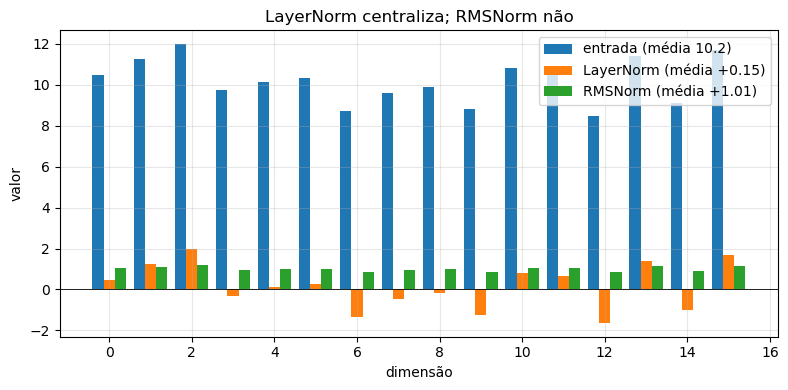

In [4]:
n = 16                                   # primeiras dims, só p/ visualizar
v_in = x1[0, :n].detach()
with torch.no_grad():
    v_ln  = ln(x1)[0, :n]
    v_rms = rmsn(x1)[0, :n]

idx = np.arange(n); w = 0.27
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(idx - w, v_in,  w, label=f"entrada (média {v_in.mean():.1f})")
ax.bar(idx,     v_ln,  w, label=f"LayerNorm (média {v_ln.mean():+.2f})")
ax.bar(idx + w, v_rms, w, label=f"RMSNorm (média {v_rms.mean():+.2f})")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("dimensão"); ax.set_ylabel("valor")
ax.set_title("LayerNorm centraliza; RMSNorm não")
ax.legend(); plt.tight_layout(); plt.show()

## B. SwiGLU — a MLP com portão

### Recapitulação: a MLP do GPT-2

O bloco feed-forward do GPT-2 é dois lineares com expansão de fator 4 e GELU no meio:

$$ \mathrm{MLP}_{\text{GPT-2}}(x) = \mathrm{GELU}(x W_1)\, W_2,
   \quad W_1 \in \mathbb{R}^{d\times 4d},\ W_2 \in \mathbb{R}^{4d\times d} $$

Contagem de parâmetros: $2 \cdot d \cdot 4d = 8d^2$ por camada (ignorando bias).

### Gated Linear Units

A família GLU (Dauphin et al. 2017) introduz um **ramo multiplicativo paralelo**:

$$ \mathrm{GLU}(x; W, V) = \sigma(xW) \odot (xV) $$

O ramo $\sigma(xW)$ funciona como um **filtro** (portão) elemento a elemento
aplicado ao ramo $xV$. Mesma dimensão de hidden, mas duas projeções em vez de uma,
e a ativação aplicada a **apenas uma** delas. Shazeer testou várias ativações $\sigma$:

| Nome | $\sigma$ | Definição |
|---|---|---|
| GLU | sigmoide | $\sigma(z)=1/(1+e^{-z})$ |
| ReGLU | ReLU | $\max(0,z)$ |
| GEGLU | GELU | $z\,\Phi(z)$ |
| **SwiGLU** | **SiLU/Swish** | $z\cdot\text{sigmoide}(z) = z/(1+e^{-z})$ |
| Bilinear | identidade | $z$ (sem ativação) |

SwiGLU venceu os benchmarks, foi adotado por PaLM e cristalizado em LLaMA.

### Definição e dimensão do hidden

$$ \mathrm{SwiGLU\text{-}MLP}(x) = \Big(\mathrm{SiLU}(x W_g) \odot (x W_u)\Big) W_d $$

com $W_g, W_u \in \mathbb{R}^{d\times h}$ (gate e up) e $W_d \in \mathbb{R}^{h\times d}$
(down). **Três** projeções em vez de duas, todas **sem bias** (bias em projeções
lineares de transformer raramente ajuda em escala).

Para manter a contagem de parâmetros equivalente à MLP GELU-4d:

$$ 3 \cdot d \cdot h = 8d^2 \implies h = \frac{8d}{3} $$

Na prática arredondamos $h$ para o múltiplo de 64 mais próximo acima, para alinhar
com o tamanho de *tile* dos tensor cores da NVIDIA:

$$ h = 64 \cdot \left\lceil \frac{8d/3}{64} \right\rceil $$

In [5]:
def compute_hidden_dim(embed_dim, multiple_of=64):
    hidden = int(8 * embed_dim / 3)
    return ((hidden + multiple_of - 1) // multiple_of) * multiple_of

# Reproduzindo a tabela de presets do projeto
print(f"{'preset':<8}{'d':>6}{'8d/3':>8}{'h (arred.)':>12}")
for name, d in [("small",128),("base",256),("medium",512),("large",768)]:
    print(f"{name:<8}{d:>6}{int(8*d/3):>8}{compute_hidden_dim(d):>12}")

preset       d    8d/3  h (arred.)
small      128     341         384
base       256     682         704
medium     512    1365        1408
large      768    2048        2048


In [6]:
class SwiGLU(nn.Module):
    def __init__(self, embed_dim, hidden_dim=None, dropout=0.1):
        super().__init__()
        if hidden_dim is None:
            hidden_dim = compute_hidden_dim(embed_dim)
        self.gate = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.up   = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.down = nn.Linear(hidden_dim, embed_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.down(F.silu(self.gate(x)) * self.up(x)))

d = 512
swiglu = SwiGLU(d)
x = torch.randn(2, 10, d)
print("shape entrada:", tuple(x.shape), "-> saida:", tuple(swiglu(x).shape))

shape entrada: (2, 10, 512) -> saida: (2, 10, 512)


In [7]:
# Verificando que a contagem de params bate com a MLP GELU-4d
class GPT2MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc = nn.Linear(d, 4*d)       # com bias, como no GPT-2
        self.proj = nn.Linear(4*d, d)
    def forward(self, x):
        return self.proj(F.gelu(self.fc(x)))

def n_params(m): return sum(p.numel() for p in m.parameters())

d = 512
h = compute_hidden_dim(d)
gpt2 = GPT2MLP(d)
swi = SwiGLU(d)
print(f"d={d}, h_swiglu={h}")
print(f"MLP GPT-2 (GELU 4d): {n_params(gpt2):,} params (~8d^2 = {8*d*d:,})")
print(f"SwiGLU (3 proj):     {n_params(swi):,} params (~3*d*h = {3*d*h:,})")
print(f"razao SwiGLU/GPT-2:  {n_params(swi)/n_params(gpt2):.3f}  (~1, por construcao)")

d=512, h_swiglu=1408
MLP GPT-2 (GELU 4d): 2,099,712 params (~8d^2 = 2,097,152)
SwiGLU (3 proj):     2,162,688 params (~3*d*h = 2,162,688)
razao SwiGLU/GPT-2:  1.030  (~1, por construcao)


As duas MLPs têm contagem de parâmetros quase idêntica — é o ponto de $h = 8d/3$.
O ganho do SwiGLU não vem de mais parâmetros, e sim de melhor uso deles:

- **Gating multiplicativo dá uma rota direta.** O ramo $xW_u$ não passa por
  não-linearidade, podendo carregar informação sem distorção; o gate controla
  quanto passa.
- **Mais expressividade por parâmetro.** A composição multiplicativa entre dois
  ramos lineares produz funções polinomiais de grau 2 em $x$, enquanto a MLP
  padrão só compõe não-linearidades pontuais com somas.
- **Melhor uso de tensor cores.** Três multiplicações menores ($d\times h$)
  competem bem com duas maiores ($d\times 4d$) e permitem mais paralelismo.

Essa `SwiGLU` vai para `src/tucanoce/model/layers/swiglu.py`.

## C. RoPE — codificar posição por rotação

### O problema dos embeddings posicionais somados

O GPT-2 codifica posição por uma embedding aprendida somada ao token embedding:

$$ h_0 = \mathrm{Embed}(x_t) + \mathrm{PosEmbed}(t) $$

Três problemas:
1. **Entrelaça conteúdo e posição** num único vetor; a rede precisa aprender a separá-los.
2. **Não extrapola:** posições $t > T_{\max}$ nunca foram treinadas.
3. **Gasta parâmetros:** $T_{\max}\cdot d$ dedicados só a posição (no medium: $512\times512 = 262$K).

### Ideia central: rotação no plano

RoPE (Su et al.) descarta a soma e em vez disso **rotaciona** as projeções $Q$ e
$K$ por um ângulo dependente da posição. Rotação preserva produto interno mas
codifica deslocamento relativo. Para um par de dimensões $(2i, 2i{+}1)$ e ângulo
$\theta$, a rotação 2D é

$$ R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix} $$

Para a posição $m$ usamos frequências $\theta_i = b^{-2i/d_h}$ (base $b = 10000$),
e a rotação completa em $d_h$ dimensões é bloco-diagonal com $d_h/2$ dessas rotações.

### A propriedade central: dependência só na posição relativa

A pontuação de atenção entre posição $m$ (query) e $n$ (key) usa
$Q'_m = R_m Q_m$ e $K'_n = R_n K_n$:

$$ \langle Q'_m, K'_n \rangle = (R_m Q_m)^\top (R_n K_n)
   = Q_m^\top R_m^\top R_n K_n = Q_m^\top R_{n-m} K_n $$

A última igualdade usa $R_m^\top R_n = R_{-m}R_n = R_{n-m}$ (rotações compõem por
soma de ângulos). **Logo a pontuação depende apenas de $n-m$**, não das posições
absolutas. Essa é a propriedade que torna o modelo robusto a extrapolar contexto —
e é o que vamos verificar numericamente.

In [8]:
# Formulacao "rotate_half" (estilo LLaMA), equivalente e mais simples em codigo.
def precompute_rope_freqs(head_dim, max_seq_len, base=10000.0):
    # theta_i = base^(-2i/head_dim), i = 0,2,4,...
    inv_freq = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    positions = torch.arange(max_seq_len).float()
    freqs = torch.outer(positions, inv_freq)      # (T, head_dim/2)
    emb = torch.cat([freqs, freqs], dim=-1)        # (T, head_dim)  duplica p/ rotate_half
    return emb.cos(), emb.sin()

def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat([-x2, x1], dim=-1)

def apply_rope(x, cos, sin):
    # x: (..., T, head_dim); cos/sin: (T, head_dim)
    cos = cos.to(x.dtype); sin = sin.to(x.dtype)
    return (x * cos) + (rotate_half(x) * sin)

head_dim, T = 64, 16
cos, sin = precompute_rope_freqs(head_dim, T)
print("cos shape:", tuple(cos.shape), "| sin shape:", tuple(sin.shape))

cos shape: (16, 64) | sin shape: (16, 64)


RoPE **é rotação**. À esquerda, o mesmo vetor 2D rotacionado por posições crescentes
$m=0,1,\dots$ (para a frequência mais rápida, $\theta_0$): cada posição gira o vetor
um pouco mais — a posição vira ângulo. À direita, as frequências $\theta_i =
b^{-2i/d_h}$ em escala semilog: dimensões baixas giram **rápido** (capturam ordem
local), altas giram **devagar** (quase constantes na janela). É a escala geométrica
que deixa o RoPE codificar posições próximas e distantes ao mesmo tempo.

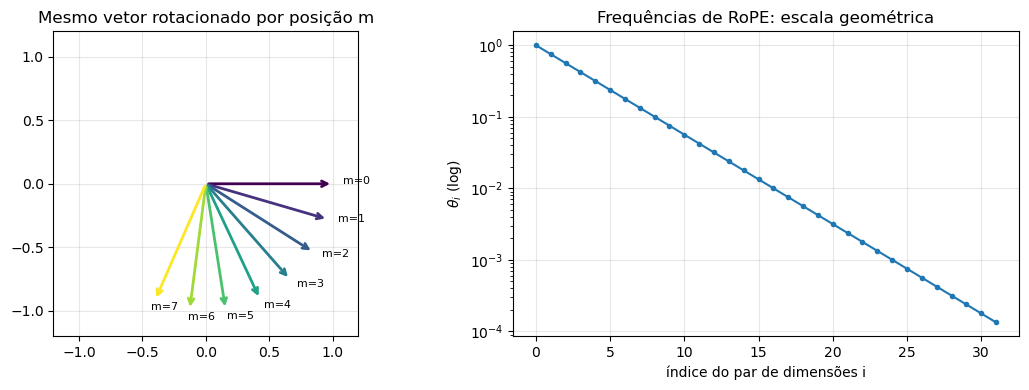

In [9]:
inv_freq = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2).float() / head_dim))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# (a) rotação do vetor por posição, na frequência mais rápida (theta_0)
theta0 = inv_freq[0].item()
base_vec = np.array([1.0, 0.0])
for m in range(8):
    ang = m * theta0 * 6      # *6 só p/ o giro ficar visível na figura
    R = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
    vx, vy = R @ base_vec
    ax1.annotate("", xy=(vx, vy), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="->", color=plt.cm.viridis(m/7), lw=2))
    ax1.text(vx*1.08, vy*1.08, f"m={m}", fontsize=8)
ax1.set_xlim(-1.2, 1.2); ax1.set_ylim(-1.2, 1.2); ax1.set_aspect("equal")
ax1.set_title("Mesmo vetor rotacionado por posição m")

# (b) frequências em escala semilog
ax2.semilogy(range(len(inv_freq)), inv_freq.numpy(), "o-", ms=3)
ax2.set_xlabel("índice do par de dimensões i"); ax2.set_ylabel(r"$\theta_i$ (log)")
ax2.set_title(r"Frequências de RoPE: escala geométrica")
plt.tight_layout(); plt.show()

In [10]:
# PROVA da invariancia relativa: <R_m q, R_n k> depende so de (n - m).
# Fixamos q e k; variamos as posicoes mantendo a mesma distancia.
head_dim, T = 64, 64
cos, sin = precompute_rope_freqs(head_dim, T)

q = torch.randn(head_dim)
k = torch.randn(head_dim)

def rope_dot(m, n):
    qm = apply_rope(q.view(1, head_dim), cos[m:m+1], sin[m:m+1])
    kn = apply_rope(k.view(1, head_dim), cos[n:n+1], sin[n:n+1])
    return (qm * kn).sum().item()

# Mesma distancia n-m=3, posicoes absolutas diferentes
d_2_5   = rope_dot(2, 5)
d_10_13 = rope_dot(10, 13)
d_40_43 = rope_dot(40, 43)
print(f"<R_2 q,  R_5 k>  = {d_2_5:.6f}")
print(f"<R_10 q, R_13 k> = {d_10_13:.6f}")
print(f"<R_40 q, R_43 k> = {d_40_43:.6f}")
assert np.allclose([d_2_5, d_10_13], [d_10_13, d_40_43], atol=1e-4)
print("\nMesma distancia relativa -> mesmo produto interno. Invariancia confirmada.")

# Distancia diferente -> produto diferente (a posicao relativa importa)
print(f"\n<R_2 q, R_8 k> (dist 6) = {rope_dot(2, 8):.6f}  != {d_2_5:.6f}")

<R_2 q,  R_5 k>  = 1.665299
<R_10 q, R_13 k> = 1.665299
<R_40 q, R_43 k> = 1.665297

Mesma distancia relativa -> mesmo produto interno. Invariancia confirmada.

<R_2 q, R_8 k> (dist 6) = 2.283677  != 1.665299


A prova numérica em uma figura. A **curva** é o produto interno $\langle R_m q, R_n
k\rangle$ em função da distância relativa $n-m$, com base fixa $m=5$. Os **pontos
vermelhos** são o mesmo cálculo para posições absolutas totalmente diferentes
($m=20$): eles caem exatamente sobre a curva. Só a distância importa — a posição
absoluta é irrelevante. É isso que dá ao RoPE robustez para extrapolar contexto.

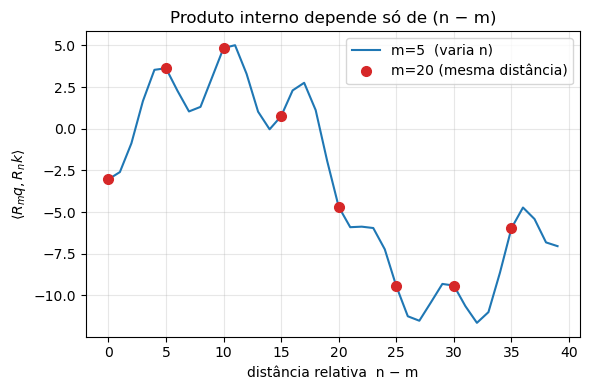

In [11]:
dists = list(range(0, 40))
curve = [rope_dot(5, 5 + d) for d in dists]        # base m=5
pts   = [rope_dot(20, 20 + d) for d in dists[::5]]  # base m=20, mesma distancia

fig, ax = plt.subplots()
ax.plot(dists, curve, "-", color="C0", label="m=5  (varia n)")
ax.plot(dists[::5], pts, "o", color="C3", ms=7, label="m=20 (mesma distância)")
ax.set_xlabel("distância relativa  n − m"); ax.set_ylabel(r"$\langle R_m q, R_n k\rangle$")
ax.set_title("Produto interno depende só de (n − m)")
ax.legend(); plt.tight_layout(); plt.show()

A pontuação de atenção com RoPE realmente só enxerga a distância relativa entre
tokens. Sobre a escolha de $b = 10000$: ela controla quão rápido a rotação se
completa dentro da janela. Modelos que precisam de contexto extremo ($> 32$K
tokens) usam bases maiores — **LLaMA-3 chegou a usar $b = 500000$** — esticando o
comprimento de onda para as posições distantes não "darem a volta".

`precompute_rope_freqs`, `rotate_half` e `apply_rope` vão para
`src/tucanoce/model/layers/rope.py`.

## D. KV-cache — geração linear em vez de quadrática

### O custo da geração ingênua

Em geração autoregressiva partimos de um prompt $x_{1:p}$ e amostramos
$x_{p+1}, x_{p+2}, \dots$ um a um. A versão direta **refaz o forward inteiro** a
cada passo:

$$ \text{Passo 1: } \mathrm{forward}([x_1,\dots,x_p]) \to \hat x_{p+1} $$
$$ \text{Passo 2: } \mathrm{forward}([x_1,\dots,x_p,\hat x_{p+1}]) \to \hat x_{p+2} $$

No passo $k$, recomputa $Q,K,V$ para todos os $p+k-1$ tokens anteriores, mesmo que
só o novo poste contribua para a próxima predição. O custo das projeções fica

$$ C^{\text{ingênuo}} = L\cdot 4d^2 \cdot \sum_{k=1}^{N}(p+k) = O(L\cdot d^2\cdot N\cdot(p+N)) $$

**quadrático em $N$**, mesmo que cada token novo só introduza uma linha nova.

### A observação-chave

A máscara causal garante que $K_i, V_i$ de qualquer $i < t$ **não mudam** quando
processamos posições $\ge t$. Logo dá para **cachear** $K, V$ de todas as posições
já processadas e, em cada passo, calcular apenas:

1. $Q_{p+k}, K_{p+k}, V_{p+k}$ (uma linha nova cada);
2. concatenar $K_{p+k}, V_{p+k}$ ao cache;
3. atenção $\mathrm{softmax}(Q_{p+k} K_{1:p+k}^\top / \sqrt{d_h})\, V_{1:p+k}$.

O custo das projeções cai para $O(L\cdot d^2\cdot N)$ — **linear em $N$**.

### Dois detalhes que quebram implementações ingênuas

- **Máscara.** No *prefill*, $Q$ e $K$ têm o mesmo comprimento → `is_causal=True`.
  No *decode* com cache, $Q$ tem 1 token mas $K$ tem $p+k$ → `is_causal` deixa de
  valer (a função do PyTorch assume $|Q|=|K|$). A regra: a query única
  naturalmente "vê" todos os keys do cache, sem máscara. Em código:
  `is_causal = Q.size(-2) == K.size(-2)`.
- **Offset de RoPE.** O token novo no passo $k$ está na posição global $p+k$, então
  a rotação correta usa $\cos_{p+k}, \sin_{p+k}$, não $\cos_0, \sin_0$.

In [12]:
# Atencao causal multi-head com RoPE e KV-cache opcional.
class CausalAttnRoPE(nn.Module):
    def __init__(self, embed_dim, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out_proj = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x, cos, sin, past_kv=None, use_cache=False):
        B, T, C = x.shape
        H, hd = self.n_heads, self.head_dim
        # projeta e quebra em cabecas: (B, H, T, hd)
        q = self.q_proj(x).view(B, T, H, hd).transpose(1, 2)
        k = self.k_proj(x).view(B, T, H, hd).transpose(1, 2)
        v = self.v_proj(x).view(B, T, H, hd).transpose(1, 2)
        # offset posicional: se ha cache, o token novo esta na posicao p+k
        offset = 0 if past_kv is None else past_kv[0].size(-2)
        c = cos[offset:offset+T]; s = sin[offset:offset+T]
        q = apply_rope(q, c, s)
        k = apply_rope(k, c, s)
        # concatena K,V ao cache (os K,V ja trazem a rotacao das posicoes originais)
        if past_kv is not None:
            k = torch.cat([past_kv[0], k], dim=-2)
            v = torch.cat([past_kv[1], v], dim=-2)
        new_kv = (k, v) if use_cache else None
        # is_causal adaptativo: True no prefill (|Q|==|K|), False no decode
        is_causal = q.size(-2) == k.size(-2)
        out = F.scaled_dot_product_attention(q, k, v, is_causal=is_causal)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out), new_kv

embed_dim, n_heads, T = 32, 4, 12
attn = CausalAttnRoPE(embed_dim, n_heads).eval()
cos, sin = precompute_rope_freqs(embed_dim // n_heads, 128)
x = torch.randn(1, T, embed_dim)
with torch.no_grad():
    y_full, _ = attn(x, cos, sin)
print("forward completo ok, saida:", tuple(y_full.shape))

forward completo ok, saida: (1, 12, 32)


In [13]:
# PROVA: gerar token-a-token COM cache == recomputar o forward inteiro SEM cache.
torch.manual_seed(1)
embed_dim, n_heads = 32, 4
attn = CausalAttnRoPE(embed_dim, n_heads).eval()
cos, sin = precompute_rope_freqs(embed_dim // n_heads, 128)

seq = torch.randn(1, 10, embed_dim)      # sequencia "ja amostrada" para comparar

# (1) SEM cache: para cada prefixo t, forward do zero e pega a ultima posicao
outs_nocache = []
with torch.no_grad():
    for t in range(1, seq.size(1) + 1):
        y, _ = attn(seq[:, :t], cos, sin)      # recomputa tudo
        outs_nocache.append(y[:, -1])           # saida da ultima posicao
outs_nocache = torch.stack(outs_nocache, dim=1)

# (2) COM cache: alimenta um token por vez, reaproveitando K,V
outs_cache = []
past = None
with torch.no_grad():
    for t in range(seq.size(1)):
        y, past = attn(seq[:, t:t+1], cos, sin, past_kv=past, use_cache=True)
        outs_cache.append(y[:, -1])
outs_cache = torch.stack(outs_cache, dim=1)

err = (outs_nocache - outs_cache).abs().max().item()
print(f"erro maximo entre com-cache e sem-cache: {err:.2e}")
assert err < 1e-5
print("KV-cache produz resultado IDENTICO ao recompute completo. Confirmado.")
print(f"tamanho final do cache K: {tuple(past[0].shape)} (B, H, T, head_dim)")

erro maximo entre com-cache e sem-cache: 8.94e-08
KV-cache produz resultado IDENTICO ao recompute completo. Confirmado.
tamanho final do cache K: (1, 4, 10, 8) (B, H, T, head_dim)


In [14]:
# Memoria do cache: 2 (K e V) * L * B * H * T * head_dim * 2 bytes (BF16)
def kv_cache_mb(L, B, H, T, head_dim):
    return 2 * L * B * H * T * head_dim * 2 / 1e6

# Preset medium do projeto: L=12, H=8, head_dim=64, B=1, T=512
print(f"cache do medium (L=12,H=8,d_h=64,T=512): {kv_cache_mb(12,1,8,512,64):.1f} MB")
print("Negligivel em qualquer GPU moderna -- o cache troca memoria barata por compute caro.")

cache do medium (L=12,H=8,d_h=64,T=512): 12.6 MB
Negligivel em qualquer GPU moderna -- o cache troca memoria barata por compute caro.


O ganho do cache em uma figura: custo acumulado das projeções $Q,K,V$ para gerar $N$
tokens. Sem cache, cada passo refaz o forward de todo o prefixo → soma **quadrática**
em $N$. Com cache, cada passo processa só a linha nova → **linear**. A distância entre
as curvas é exatamente o compute que o cache economiza — e cresce com o contexto.

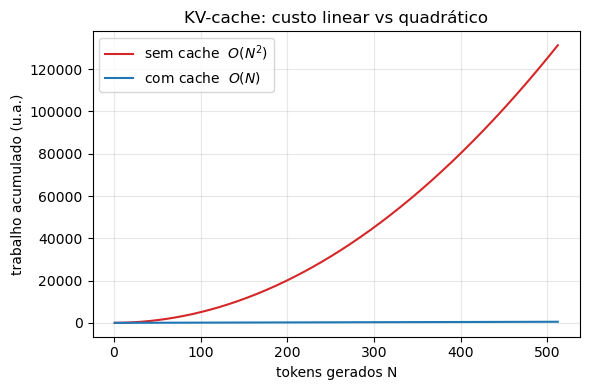

In [15]:
N = np.arange(1, 513)
naive  = np.cumsum(N).astype(float)   # O(N^2): passo k custa ~k -> soma quadratica
cached = N.astype(float)              # O(N):   passo k custa ~1 -> soma linear

fig, ax = plt.subplots()
ax.plot(N, naive,  label=r"sem cache  $O(N^2)$", color="C3")
ax.plot(N, cached, label=r"com cache  $O(N)$",  color="C0")
ax.set_xlabel("tokens gerados N"); ax.set_ylabel("trabalho acumulado (u.a.)")
ax.set_title("KV-cache: custo linear vs quadrático")
ax.legend(); plt.tight_layout(); plt.show()

O KV-cache dá exatamente o mesmo resultado que recomputar tudo — só que linear em
vez de quadrático. Um detalhe de API que o projeto destaca (nb 04): o `forward`
deve retornar o cache **só quando pedido** (`use_cache=True`). Se sempre
retornasse, as referências aos tensores $K,V$ persistiriam após o forward,
anulando o *gradient checkpointing* do treino. Por isso o retorno é condicional.

Essa atenção com cache vai para `src/tucanoce/model/layers/attention.py`.

## Resumo — os quatro upgrades

| Componente | Fórmula-chave | Verificação feita | Stub |
|---|---|---|---|
| **RMSNorm** | $\gamma \odot x/\sqrt{\text{mean}(x^2)+\varepsilon}$ | $\text{RMS}^2=\sigma^2+\mu^2$; = LayerNorm p/ média 0 | `layers/rmsnorm.py` |
| **SwiGLU** | $(\text{SiLU}(xW_g)\odot xW_u)W_d$, $h=8d/3$ | params ≈ MLP GELU-4d | `layers/swiglu.py` |
| **RoPE** | $R_m q$, $\theta_i=b^{-2i/d_h}$ | $\langle R_m q, R_n k\rangle$ só depende de $n-m$ | `layers/rope.py` |
| **KV-cache** | cacheia $K,V$; `is_causal=|Q|{=}{=}|K|` | geração cacheada = recompute | `layers/attention.py` |

**Por que juntas.** Cada troca é independente em código, mas o modelo final —
RMSNorm em pre-norm + blocos com SwiGLU + atenção com RoPE + KV-cache na inferência
— é a receita LLaMA que a comunidade aberta convergiu. Nenhuma delas é
"esperta" isoladamente; o valor está em terem sido validadas em escala e ficarem
mais baratas *e* melhores que o que substituíram.

**Caminho de evolução.** Papers na fonte: RMSNorm (Zhang & Sennrich, 2019),
GLU Variants (Shazeer, 2020), RoFormer/RoPE (Su et al., 2021). Ferramenta para
comparar: as implementações de referência do LLaMA e do `nanoGPT` — leia lado a
lado com o que você escreveu aqui.

**Direções que o projeto deixa para depois:** GQA (Grouped-Query Attention) reduz o
KV-cache dividindo cabeças de K/V; Muon como otimizador; SFT + LoRA para virar
assistente. Ficam para o roadmap do `ARCHITECTURE.md`.

Próximo: **`05_pipeline_dados.ipynb`** — scraping, limpeza e o gargalo escondido do
`chunked dataset`.